In [16]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Création de données
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modèle très complexe
overfit_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,)),
    Dense(500, activation='relu'),
    Dense(500, activation='relu'),
    Dense(1, activation='sigmoid')
])

overfit_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = overfit_model.fit(X_train, y_train,
                           epochs=200,
                           validation_data=(X_test, y_test),
                           verbose=1)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8000 - loss: 0.5357 - val_accuracy: 0.9000 - val_loss: 0.2997
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8286 - loss: 0.3476 - val_accuracy: 0.9111 - val_loss: 0.2350
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8381 - loss: 0.3481 - val_accuracy: 0.9111 - val_loss: 0.2263
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8333 - loss: 0.3283 - val_accuracy: 0.8444 - val_loss: 0.3098
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8524 - loss: 0.2921 - val_accuracy: 0.9111 - val_loss: 0.2253
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8571 - loss: 0.2821 - val_accuracy: 0.9000 - val_loss: 0.2090
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8571 - loss: 0.2694 - val_accuracy: 0.8889 - val_loss: 0.2250
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8857 - loss: 0.2495 - val_accuracy: 0.8889 - val_loss:

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step


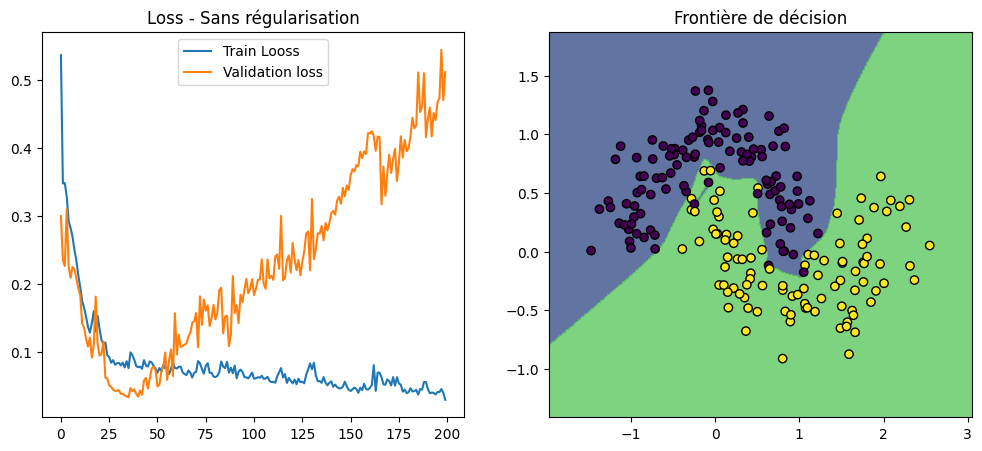

In [17]:
# Courbes d'apprentissage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Looss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss - Sans régularisation')
plt.legend()

# Frontière de décision
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) > 0.5
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title("Frontière de décision")

plt.subplot(1, 2, 2)
plot_decision_boundary(overfit_model, X_train, y_train)
plt.show()

In [18]:
from tensorflow.keras.regularizers import l2

#  régularisation L2
regularized_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,), kernel_regularizer=l2(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid')
])

regularized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

reg_history = regularized_model.fit(X_train, y_train,
                                   epochs=200,
                                   validation_data=(X_test, y_test),
                                   verbose=0)

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step


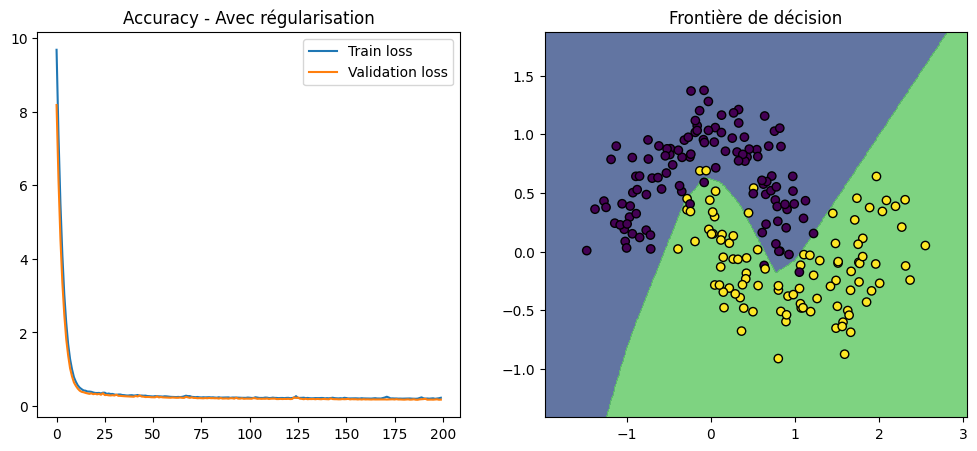

In [19]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(reg_history.history['loss'], label='Train loss')
plt.plot(reg_history.history['val_loss'], label='Validation loss')
plt.title('Accuracy - Avec régularisation')
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(regularized_model, X_train, y_train)
plt.show()

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
5172/5172 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step


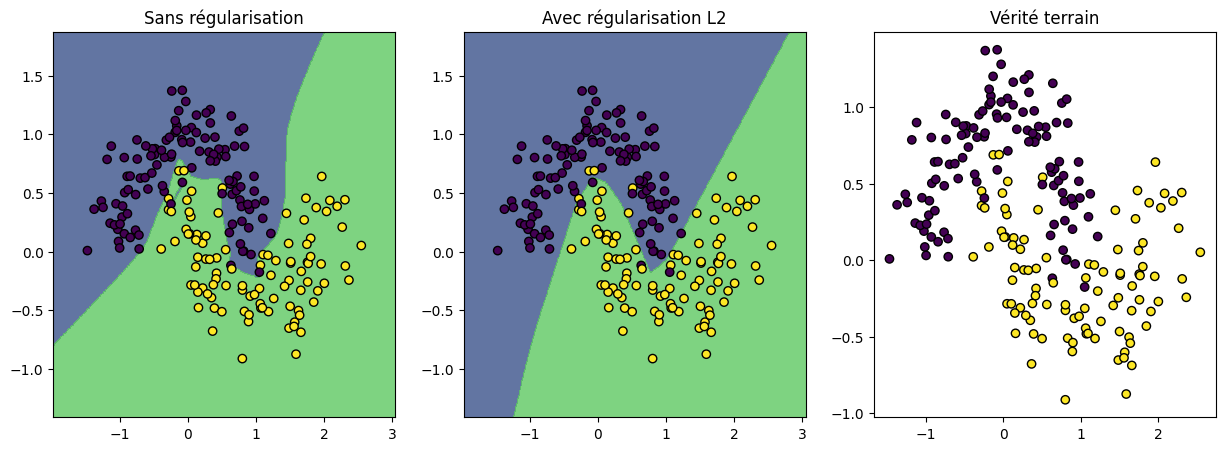

In [20]:
plt.figure(figsize=(15, 5))

# Sans régularisation
plt.subplot(1, 3, 1)
plot_decision_boundary(overfit_model, X_train, y_train)
plt.title("Sans régularisation")

# Avec régularisation
plt.subplot(1, 3, 2)
plot_decision_boundary(regularized_model, X_train, y_train)
plt.title("Avec régularisation L2")

# Vérité terrain
plt.subplot(1, 3, 3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k')
plt.title("Vérité terrain")
plt.show()

# Modèle avec régularisation L1

In [21]:
from tensorflow.keras.regularizers import l1, l1_l2
l1_model = Sequential([
    Dense(500, activation="relu", input_shape=(2,), kernel_regularizer=l1(0.01)),
    Dense(500, activation="relu", kernel_regularizer=l1(0.01)),
    Dense(500, activation="relu", kernel_regularizer=l1(0.01)),
    Dense(1, activation="sigmoid")
])

l1_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_l1 = l1_model.fit(X_train, y_train,
                          epochs=200,
                          validation_data=(X_test, y_test),
                          verbose=0)


# Modèle avec régularisation ElasticNet (L1 + L2)

In [22]:
elastic_model = Sequential([
    Dense(500, activation="relu", input_shape=(2,), kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(500, activation="relu", kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(500, activation="relu", kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(1, activation="sigmoid")
])

elastic_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_elastic = elastic_model.fit(X_train, y_train,
                                    epochs=200,
                                    validation_data=(X_test, y_test),
                                    verbose=0)
print("ElasticNet model trained.")

ElasticNet model trained.


# Courbes d'apprentissage - Régularisation L1

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step


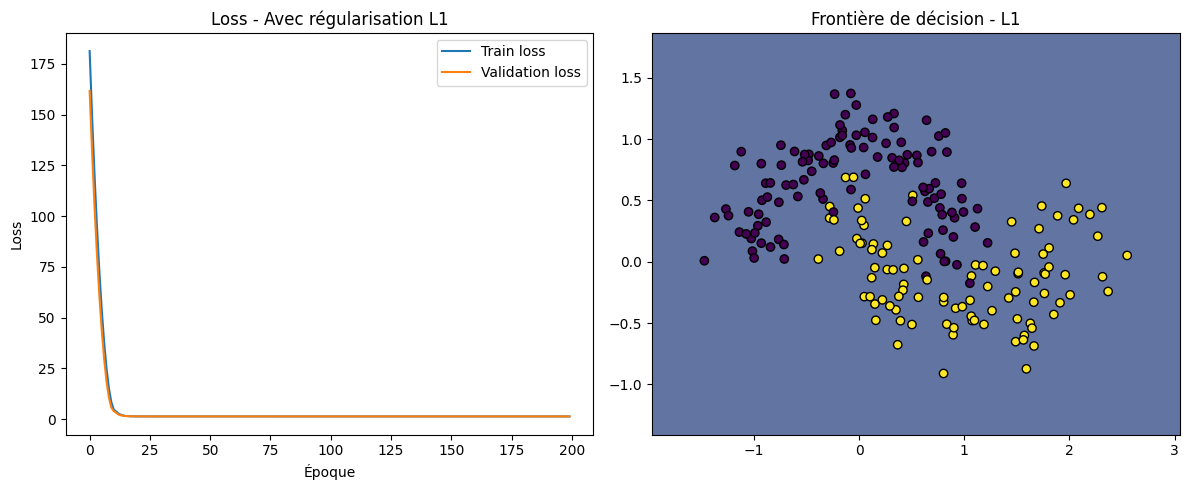

In [23]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_l1.history["loss"], label="Train loss")
plt.plot(history_l1.history["val_loss"], label="Validation loss")
plt.title("Loss - Avec régularisation L1")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(l1_model, X_train, y_train)
plt.title("Frontière de décision - L1")
plt.tight_layout()
plt.show()

# Courbes d'apprentissage - Régularisation ElasticNet

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step


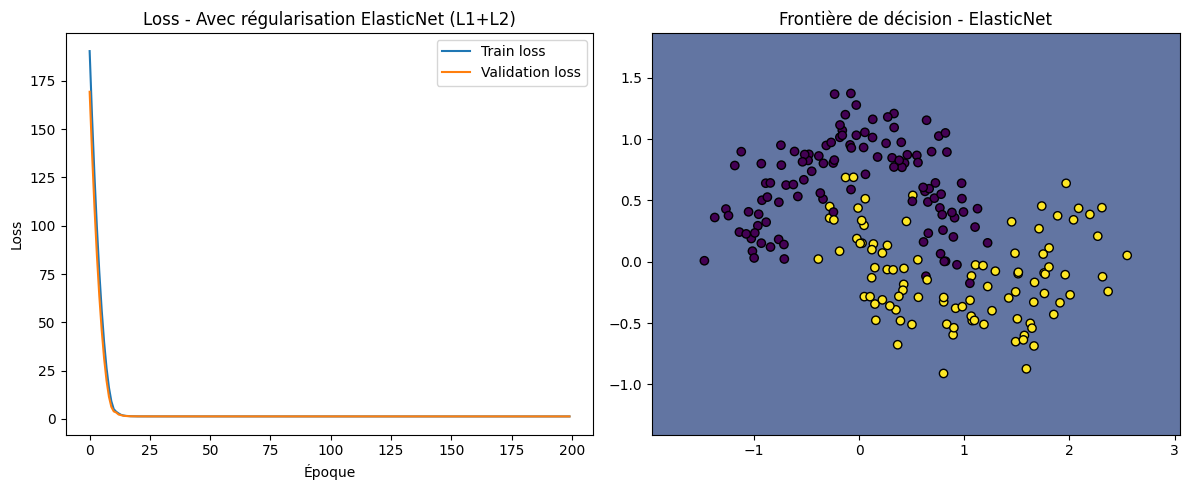

In [24]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_elastic.history["loss"], label="Train loss")
plt.plot(history_elastic.history["val_loss"], label="Validation loss")
plt.title("Loss - Avec régularisation ElasticNet (L1+L2)")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(elastic_model, X_train, y_train)
plt.title("Frontière de décision - ElasticNet")
plt.tight_layout()
plt.show()

# ── Comparaison finale : 4 modèles

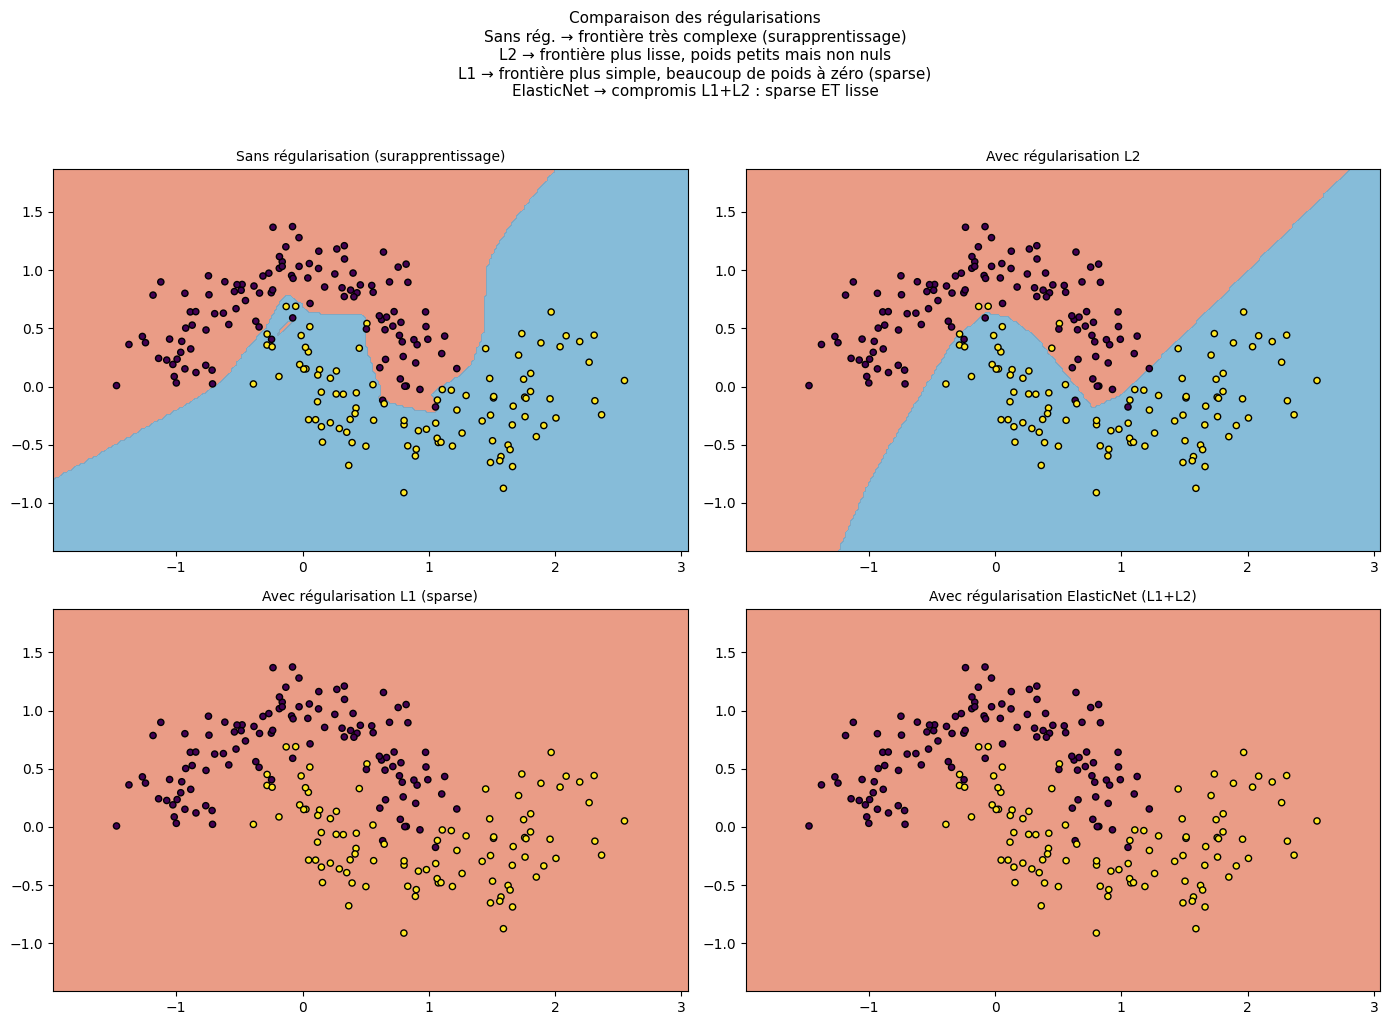

Figure sauvegardée : comparaison_regularisations.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Comparaison des régularisations\n"
    "Sans rég. → frontière très complexe (surapprentissage)\n"
    "L2 → frontière plus lisse, poids petits mais non nuls\n"
    "L1 → frontière plus simple, beaucoup de poids à zéro (sparse)\n"
    "ElasticNet → compromis L1+L2 : sparse ET lisse",
    fontsize=11, y=1.02
)

models_info = [
    (overfit_model,     "Sans régularisation (surapprentissage)", axes[0, 0]),
    (regularized_model, "Avec régularisation L2",                 axes[0, 1]),
    (l1_model,          "Avec régularisation L1 (sparse)",        axes[1, 0]),
    (elastic_model,     "Avec régularisation ElasticNet (L1+L2)", axes[1, 1]),
]

for model, title, ax in models_info:
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0) > 0.5
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap="RdBu")
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors="k", s=20)
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.savefig("comparaison_regularisations.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : comparaison_regularisations.png")


# ── Tableau récapitulatif des performances ─

In [26]:

results = {}
for name, model in [("Sans rég.", overfit_model),
                    ("L2",        regularized_model),
                    ("L1",        l1_model),
                    ("ElasticNet", elastic_model)]:
    _, train_acc = model.evaluate(X_train, y_train, verbose=0)
    _, test_acc  = model.evaluate(X_test,  y_test,  verbose=0)
    results[name] = {"Train acc": f"{train_acc:.4f}", "Test acc": f"{test_acc:.4f}"}

col1, col2, col3 = "Modele", "Train acc", "Test acc"
print(f"{col1:<15} {col2:>10} {col3:>10}")
print("-" * 38)
for name, scores in results.items():
    train = scores["Train acc"]
    test  = scores["Test acc"]
    print(f"{name:<15} {train:>10} {test:>10}")


Modele           Train acc   Test acc
--------------------------------------
Sans rég.           0.9857     0.9889
L2                  0.9571     0.9778
L1                  0.5333     0.4222
ElasticNet          0.5333     0.4222
